In [1]:
from qiskit_aer import AerSimulator
from qiskit import transpile


In [2]:
import numpy as np
from qiskit.quantum_info import Operator, SparsePauliOp
# Define Λ=15, and the annihilation operator a 
Λ = 15
dim = Λ + 1

a = np.zeros((dim, dim))

for n in range(1, dim):
    a[n-1, n] = np.sqrt(n)

a_op = Operator(a)
a_op_4q = Operator(a)


In [3]:
### Parameters
# Parameters
dt = 1.0
mpsi = 1
b = 1
eps = [3.30, 1.86, 1.0, 1.86]
n_steps = 5
g=2

In [4]:
from qiskit import QuantumCircuit
# Qubit index:

#0  → fermion 0
#1  → fermion 1

#2  → boson mode 0, bit 0 (LSB)
#3  → boson mode 0, bit 1
#4  → boson mode 0, bit 2
#5  → boson mode 0, bit 3 (MSB)

#6–9   → boson mode 1
##14–17 → boson mode 3
qc = QuantumCircuit(18)


In [5]:


### Define the Fermion part as a function
def fermion_trotter_step(qc, dt, mpsi, b):
    """
    Apply one first-order Trotter step of the fermionic Hamiltonian:
    
        H_f = mψ Z1 + (1/2b) X1 + (1/2b) X0 X1
    
    on qubits:
        0 → fermion 0
        1 → fermion 1
    """

    # --- mψ Z1 term ---
    qc.rz(2 * mpsi * dt, 1)

    # --- (1/2b) X1 term ---
    qc.rx(2 * (dt / (2 * b)), 1)

    # --- (1/2b) X0 X1 term ---
    theta = dt / (2 * b)

    # Convert XX → ZZ via H gates
    qc.h(0)
    qc.h(1)

    # Implement e^{-i theta Z0 Z1}
    qc.cx(0, 1)
    qc.rz(2 * theta, 1)
    qc.cx(0, 1)

    # Rotate back
    qc.h(0)
    qc.h(1)

In [6]:
### Define Bosonic part as a function
def boson_trotter_step(qc, dt, eps, boson_start=2, qubits_per_mode=4):
    """
    Apply one Trotter step of the bosonic free Hamiltonian:

        H_b = sum_m eps[m] a_m^† a_m

    using binary encoding of number operator.

    Parameters:
        qc               : QuantumCircuit
        dt               : time step
        eps              : list of boson energies
        boson_start      : first boson qubit index (default = 2)
        qubits_per_mode  : number of qubits per boson mode (default = 4)
    """

    for m, energy in enumerate(eps):

        base = boson_start + qubits_per_mode * m

        for k in range(qubits_per_mode):

            weight = 2**k
            phi = energy * weight * dt

            qc.rz(phi, base + k)

In [7]:

## Building a+a^\dagger
adag_op = a_op.adjoint()
X_op = a_op + adag_op
#convert to Pauli decomposition

X_pauli = SparsePauliOp.from_operator(X_op)
print("Number of Pauli terms:", len(X_pauli.paulis))

Number of Pauli terms: 32


In [8]:
def embed_pauli(pauli_op, start, total_qubits):
    """
    Embed a k-qubit SparsePauliOp into a larger register
    starting at qubit index 'start'.
    """
    new_terms = []

    for p, coeff in zip(pauli_op.paulis, pauli_op.coeffs):
        label = p.to_label()

        # pad with identities
        full_label = (
            "I" * start
            + label
            + "I" * (total_qubits - start - len(label))
        )

        new_terms.append((full_label, coeff))

    return SparsePauliOp.from_list(new_terms)


In [9]:
def build_interaction_hamiltonian(g, b, eps,
                                  X0_full, X_pauli,
                                  a_op, embed_pauli):

    pref = g * np.sqrt(b / 32)

    # ---------- Mode 0 ----------
    coeff0 = pref / np.sqrt(eps[0])# Co-efficient for 0th Boson
    # Mode0 couples to 2Z1
    Z1 = SparsePauliOp.from_list([("IZ" + "I"*16, 1.0)])
    H_fb0 = 2 * coeff0 * X0_full.compose(Z1) ## Yukawa for Boson0

    # ---------- Mode 1 ----------
    coeff1 = pref / np.sqrt(eps[1])
    ## a
    a1_full = embed_pauli(
        SparsePauliOp.from_operator(a_op),
        start=6, total_qubits=18
    )
    ## adagger
    adag1_full = embed_pauli(
        SparsePauliOp.from_operator(a_op.adjoint()),
        start=6, total_qubits=18
    )
    ## Build spin operator Z0 and Z0Z1
    Z0 = SparsePauliOp.from_list([("ZI" + "I"*16, 1.0)])
    ZZ = SparsePauliOp.from_list([("ZZ" + "I"*16, 1.0)])

    term11 = (1 - 1j) * adag1_full.compose(Z0)
    term21 = (1 + 1j) * adag1_full.compose(ZZ)
    term31 = (1 + 1j) * a1_full.compose(Z0)
    term41 = (1 - 1j) * a1_full.compose(ZZ)

    H_fb1 = coeff1 * (term11 + term21 + term31 + term41)

    # ---------- Mode 2 ----------
    coeff2 = pref / np.sqrt(eps[2])

    X2_full = embed_pauli(X_pauli, start=10, total_qubits=18)
    # Build spin operator P2=-2I
    I_spin = SparsePauliOp.from_list([("II" + "I"*16, 1.0)])

    H_fb2 = 2 * coeff2 * X2_full.compose(I_spin)

    # ---------- Mode 3 ----------
    coeff3 = pref / np.sqrt(eps[3])

    a3_full = embed_pauli(
        SparsePauliOp.from_operator(a_op),
        start=13, total_qubits=18
    )

    adag3_full = embed_pauli(
        SparsePauliOp.from_operator(a_op.adjoint()),
        start=13, total_qubits=18
    )
    ## Using spin operators Z0 and Z0Z1 as in Mode 1
    term13 = (1 + 1j) * adag3_full.compose(Z0)
    term23 = (1 - 1j) * adag3_full.compose(ZZ)
    term33 = (1 - 1j) * a3_full.compose(Z0)
    term43 = (1 + 1j) * a3_full.compose(ZZ)

    H_fb3 = coeff3 * (term13 + term23 + term33 + term43)

    # ---------- Total Interaction ----------
    H_int = (H_fb0 + H_fb1 + H_fb2 + H_fb3).simplify()

    # Enforce real coefficients (numerical cleanup)
    H_int = SparsePauliOp(
        H_int.paulis,
        coeffs=np.real(H_int.coeffs)
    )

    return H_int

In [10]:
## embed into full registrar
X0_full = embed_pauli(X_pauli, start=2, total_qubits=18) ##X operator for 0 boson
print(X0_full.num_qubits)         
print(len(X0_full.paulis)) 

18
32


In [11]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
### Build Interaction Evolution Gate
def build_interaction_gate(g):

    H_int = build_interaction_hamiltonian(
        g, b, eps,
        X0_full, X_pauli,
        a_op, embed_pauli
    )

    return PauliEvolutionGate(
        H_int,
        time=dt,
        synthesis=LieTrotter(reps=1)
    )

In [12]:
def run_shot_simulation(g, n_steps, shots=1000):

    simulator = AerSimulator()
    times = np.arange(n_steps + 1)

    spin_probs = []
    interaction_gate = build_interaction_gate(g)
    for step in range(n_steps + 1):

        qc = QuantumCircuit(18, 2)  # 2 classical bits for qubits 0 and 1

        # Apply evolution up to current step
        for _ in range(step):
            fermion_trotter_step(qc, dt, mpsi, b)
            boson_trotter_step(qc, dt, eps)
            qc.append(interaction_gate, qc.qubits)

        # Measure only fermion qubits
        qc.measure(0, 0)
        qc.measure(1, 1)

        # Transpile and run
        tqc = transpile(qc, simulator)
        result = simulator.run(tqc, shots=shots).result()
        counts = result.get_counts()

        # Extract probabilities
        P00 = counts.get('00', 0) / shots
        P01 = counts.get('10', 0) / shots  # swapped
        P10 = counts.get('01', 0) / shots  # swapped
        P11 = counts.get('11', 0) / shots

        spin_probs.append([P00, P01, P10, P11])

    return times, np.array(spin_probs)

In [13]:
##Running for g=2 and 0
times, probs_g2 = run_shot_simulation(g=2, n_steps=5)
times, probs_g0 = run_shot_simulation(g=0, n_steps=5)

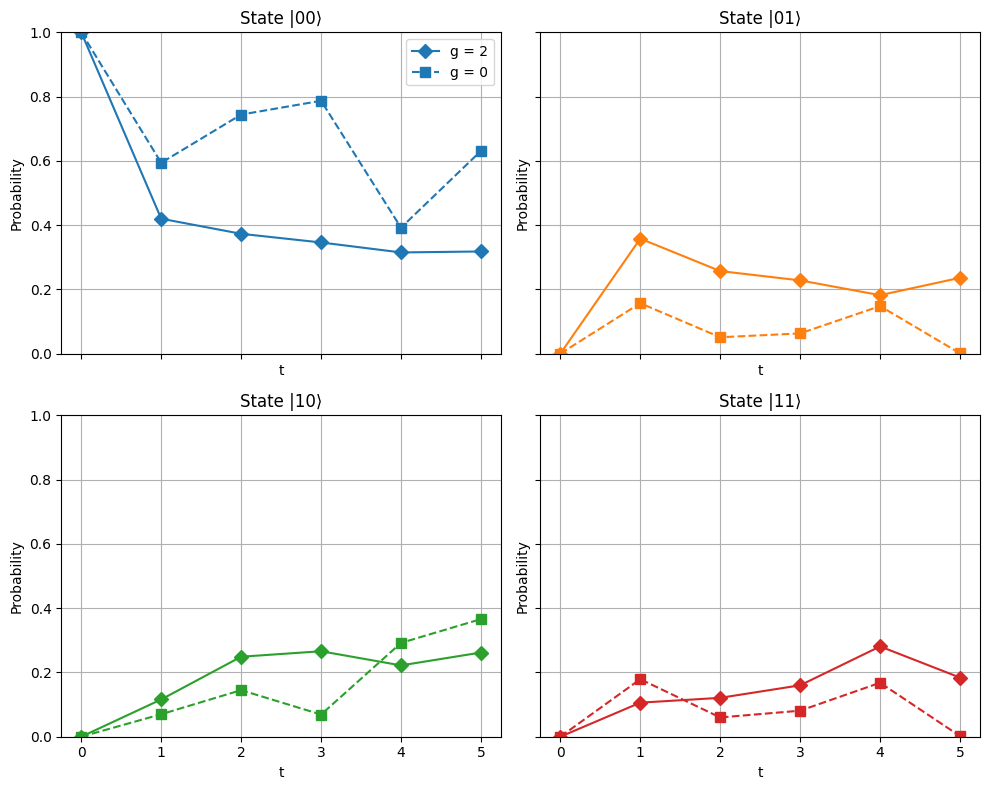

In [14]:
import matplotlib.pyplot as plt

labels = ["00", "01", "10", "11"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(4):

    # g = 2 → rhombus markers
    
    axes[i].plot(
        times,
        probs_g2[:, i],
        marker='D',        # Rhombus marker
        linestyle='-',     
        color=colors[i],
        label="g = 2",
        markersize=7
    )
    # g = 0 → dashed circles
    axes[i].plot(
        times,
        probs_g0[:, i],
        marker='s',        # Square marker
        linestyle='--',     
        color=colors[i],
        label="g = 0",
        markersize=7
    )

    axes[i].set_title(f"State |{labels[i]}⟩")
    axes[i].set_ylim(0, 1)
    axes[i].set_xlabel("t")
    axes[i].set_ylabel("Probability")
    axes[i].grid(True)

# Put legend only once
axes[0].legend()

plt.tight_layout()
plt.show()

In [17]:
simulator = AerSimulator()
    #times = np.arange(n_steps + 1)

spin_probs = []
interaction_gate = build_interaction_gate(g)
    #for step in range(n_steps + 1):

qc = QuantumCircuit(18, 2)  # 2 classical bits for qubits 0 and 1

        # Apply evolution up to current step
#for _ in range(step):
fermion_trotter_step(qc, dt, mpsi, b)
boson_trotter_step(qc, dt, eps)
qc.append(interaction_gate, qc.qubits)
qc.decompose().draw("mpl")